In [30]:
import os
import time
import warnings

# Data manipulation and analysis
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
from skimage.measure import EllipseModel

# Astropy modules
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.stats import sigma_clip
from astropy.visualization import simple_norm
from astropy.wcs import WCS
import regions

# Matplotlib for plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Ellipse

# Scipy and related modules
import scipy.sparse as sp
from scipy.ndimage import gaussian_filter
from scipy.signal import find_peaks, peak_prominences

# Spectral cube handling
from spectral_cube import SpectralCube as sc

# Progress bar
from tqdm.notebook import trange

# Additional libraries
from kneed import KneeLocator

# Multithreading
from joblib import Parallel, delayed

np.seterr(divide="ignore", invalid="ignore")
np.set_printoptions(precision=10, suppress=True)
plt.rcParams.update({'figure.max_open_warning': 0, 'font.size': 12})
delta_min = 1e-12

%matplotlib widget

In [37]:
# Define the source and target cube patterns
crafts_pattern = "./CRAFTS_RA{ra}_DEC-13_2_corrected_{sign}.fits"

# Define RA ranges and signs
ra_ranges = ["60_80", "80_100", "100_120", "120_140"]
signs = ["+", "-"]
moments = [0, 1, 2]

ra = ra_ranges[0]
sign = signs[1]

crafts_file = crafts_pattern.format(ra=ra, sign=sign)

cube = sc.read(crafts_file).with_spectral_unit(u.km / u.s)
velocities = cube.spectral_axis.value
data = cube.unmasked_data[:, :, :].value
cube

SpectralCube with shape=(995, 600, 800) and unit=K:
 n_x:    800  type_x: RA---CAR  unit_x: deg    range:    60.012500 deg:   79.987500 deg
 n_y:    600  type_y: DEC--CAR  unit_y: deg    range:   -12.987500 deg:    1.987500 deg
 n_s:    995  type_s: VRAD      unit_s: km / s  range:     -255.098 km / s:     -55.022 km / s

In [38]:
v_min = np.min(velocities)
v_max = np.max(velocities)
print(f"Velocity range: {v_min:.2f} km/s to {v_max:.2f} km/s")

Velocity range: -255.10 km/s to -55.02 km/s


In [39]:
hipass_file = "./HIPASS/HIPASS_mosaic_cube_K.fits"
hipass_cube_K = sc.read(hipass_file, unit="K").with_spectral_unit(u.km / u.s)
hipass_cube_K = hipass_cube_K.subcube(zlo=v_min*u.km/u.s, zhi=v_max*u.km/u.s)
hipass_velocities = hipass_cube_K.spectral_axis.value
hipass_data = hipass_cube_K.unmasked_data[:, :, :].value
hipass_cube_K

SpectralCube with shape=(17, 226, 1201) and unit=K:
 n_x:   1201  type_x: RA---CAR  unit_x: deg    range:    60.020823 deg:  140.020827 deg
 n_y:    226  type_y: DEC--CAR  unit_y: deg    range:   -13.022828 deg:    1.977172 deg
 n_s:     17  type_s: VRAD      unit_s: km / s  range:     -261.247 km / s:     -50.186 km / s

In [40]:
ds9_str = 'fk5; circle(71.29, 1.46, 0.1)'
subcube = cube.subcube_from_ds9region(ds9_str)
spectrum = subcube.mean(axis=(1, 2))
spectrum

<OneDSpectrum [-0.1027535   ,-0.020204157 ,-0.06491347  ,-0.102453    ,
               -0.014093889 , 0.005349126 ,-0.0011832499,-0.021005763 ,
               -0.016443217 , 0.04130844  , 0.0018921809, 0.037908405 ,
               -0.0028454398,-0.006929079 , 0.030863084 , 0.0020395874,
                0.07481637  , 0.0020910932, 0.011209239 , 0.004278921 ,
                0.04655748  ,-0.02110311  , 0.024833487 , 0.029069398 ,
                0.036324862 , 0.043806326 , 0.03747179  , 0.02979737  ,
                0.05161466  , 0.031133005 , 0.051078457 , 0.04179744  ,
                0.11675987  , 0.09498097  , 0.0245789   , 0.009074687 ,
                0.10199185  , 0.11958851  , 0.06170546  , 0.14405991  ,
                0.061190568 , 0.088239595 , 0.16474497  , 0.1397194   ,
                0.14456894  , 0.09690242  , 0.103760354 , 0.06449819  ,
                0.21142879  , 0.14055876  , 0.26622662  , 0.1601334   ,
                0.14717533  , 0.15315004  , 0.16674285  , 0.1762

In [41]:
hipass_subcube = hipass_cube_K.subcube_from_ds9region(ds9_str)
hipass_spectrum = hipass_subcube.mean(axis=(1, 2))
hipass_spectrum

<OneDSpectrum [ 0.0053267685, 0.0052855597,-0.0057569882, 0.0053829059,
               -0.0089689427, 0.0015560456,-0.0131801793,-0.0146678402,
               -0.0096208509,-0.0511983642,-0.0495274865,-0.0374438658,
                0.1416754721, 0.8773546503, 0.6617092866, 0.2815145967,
               -0.1846644875] K>

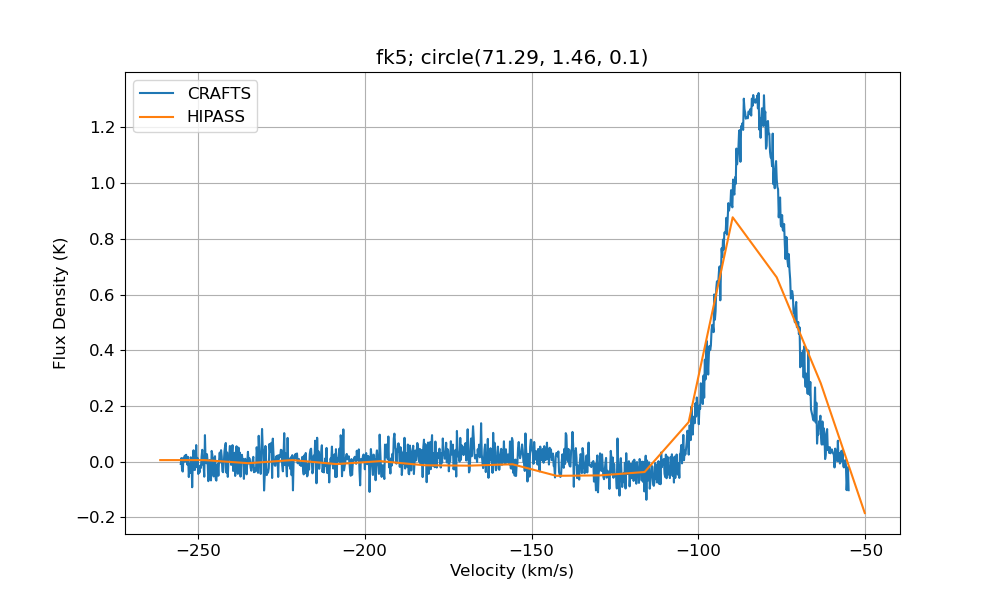

In [42]:
fig = plt.figure(figsize=(10, 6))
plt.plot(velocities, spectrum, label="CRAFTS")
plt.plot(hipass_velocities, hipass_spectrum, label="HIPASS")
plt.xlabel("Velocity (km/s)")
plt.ylabel("Flux Density (K)")
plt.title(ds9_str)
plt.legend()
plt.grid()
plt.show()